# 📘 Exercice 7 — Analyse multivariable avec SymPy

---

Ce notebook présente une **analyse complète et professionnelle** des fonctions suivantes :

| Fonction | Expression |
|----------|------------|
| $f(x,y)$ | $x^2 + y^2$ |
| $g(x,y)$ | $x^3 + y^3 - 3xy$ |
| $h(x,y)$ | $2x^3 - y^4 - 3x^2$ |
| $t(x,y)$ | $x^2 + y^2 - 4x - 6y + 13$ |

---

### 🎯 Objectifs

Pour chaque fonction, nous allons :

1. Définir les variables et la fonction
2. Calculer les **dérivées partielles** (gradient)
3. Trouver les **points critiques**
4. Calculer la **matrice Hessienne**
5. **Analyser** la nature des points critiques
6. Évaluer la **Hessienne au point critique**
7. Étudier les **valeurs propres**
8. Calculer la **valeur de la fonction** au point critique
9. Tracer les **courbes de niveau** avec les points critiques

---
## 📌 Rappel théorique — Dérivées partielles et gradient

Pour une fonction de deux variables $F(x,y)$, le **gradient** est défini par :

$$
\nabla F = \left( \frac{\partial F}{\partial x},\ \frac{\partial F}{\partial y} \right)
$$

Un **point critique** est un point $(x_0, y_0)$ où les deux dérivées partielles s'annulent simultanément :

$$
\frac{\partial F}{\partial x} = 0 \qquad \text{et} \qquad \frac{\partial F}{\partial y} = 0
$$

---
## 📌 Rappel théorique — Matrice Hessienne

La **matrice Hessienne** d'une fonction $F(x,y)$ est la matrice des dérivées secondes :

$$
H_F(x,y) =
\begin{pmatrix}
F_{xx} & F_{xy} \\
F_{yx} & F_{yy}
\end{pmatrix}
= \begin{pmatrix}
\dfrac{\partial^2 F}{\partial x^2} & \dfrac{\partial^2 F}{\partial x \partial y} \\[10pt]
\dfrac{\partial^2 F}{\partial y \partial x} & \dfrac{\partial^2 F}{\partial y^2}
\end{pmatrix}
$$

### 🔍 Critère de classification d'un point critique $(x_0, y_0)$ :

| Condition | Nature du point |
|-----------|----------------|
| $\det(H) > 0$ et $F_{xx} > 0$ | **Minimum local** ✅ |
| $\det(H) > 0$ et $F_{xx} < 0$ | **Maximum local** ✅ |
| $\det(H) < 0$ | **Point selle** ⚠️ |
| $\det(H) = 0$ | **Cas indéterminé** ❓ |

---
## 🧮 Étape 1 — Définition des variables et des fonctions

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

# Paramètres d'affichage SymPy
sp.init_printing(use_latex='mathjax')

# ── Définition des variables symboliques ──────────────────
x, y = sp.symbols('x y', real=True)

# ── Fonctions de l'exercice ───────────────────────────────
f = x**2 + y**2
g = x**3 + y**3 - 3*x*y
h = 2*x**3 - y**4 - 3*x**2
t = x**2 + y**2 - 4*x - 6*y + 13

print("Fonctions définies :")
print(f"  f(x,y) = ", end=""); display(f)
print(f"  g(x,y) = ", end=""); display(g)
print(f"  h(x,y) = ", end=""); display(h)
print(f"  t(x,y) = ", end=""); display(t)

Fonctions définies :
  f(x,y) = 

 2    2
x  + y 

  g(x,y) = 

 3            3
x  - 3⋅x⋅y + y 

  h(x,y) = 

   3      2    4
2⋅x  - 3⋅x  - y 

  t(x,y) = 

 2          2           
x  - 4⋅x + y  - 6⋅y + 13

---
# 🔷 Analyse de $f(x,y) = x^2 + y^2$

## 2) Gradient de $f$

In [5]:
# ── Dérivées partielles de f ──────────────────────────────
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

print("Gradient de f(x,y) :")
print("  ∂f/∂x = ", end=""); display(df_dx)
print("  ∂f/∂y = ", end=""); display(df_dy)

grad_f = sp.Matrix([df_dx, df_dy])
print("\n∇f = "); display(grad_f)

Gradient de f(x,y) :
  ∂f/∂x = 

2⋅x

  ∂f/∂y = 

2⋅y


∇f = 


⎡2⋅x⎤
⎢   ⎥
⎣2⋅y⎦

## 3) Résolution des équations du gradient — Points critiques de $f$

On résout le système :
$$
\frac{\partial f}{\partial x} = 0 \qquad \text{et} \qquad \frac{\partial f}{\partial y} = 0
$$

In [8]:
# ── Points critiques de f ─────────────────────────────────
pc_f = sp.solve([df_dx, df_dy], [x, y], dict=True)

print("Points critiques de f :")
for i, pt in enumerate(pc_f):
    print(f"  Point {i+1} : {pt}")

Points critiques de f :
  Point 1 : {x: 0, y: 0}


## 4) Calcul de la matrice Hessienne de $f$

In [11]:
# ── Matrice Hessienne de f ────────────────────────────────
H_f = sp.hessian(f, (x, y))

print("Matrice Hessienne de f :")
display(H_f)

det_H_f = H_f.det()
print("\nDéterminant de H_f =", det_H_f)

Matrice Hessienne de f :


⎡2  0⎤
⎢    ⎥
⎣0  2⎦


Déterminant de H_f = 4


## 5) Hessienne évaluée au point critique de $f$

In [14]:
# ── Hessienne au point critique ───────────────────────────
H_f_pc = H_f.subs(pc_f[0])

print("Hessienne de f au point critique", pc_f[0], ":")
display(H_f_pc)

det_val = H_f_pc.det()
f_xx_val = H_f_pc[0, 0]
print(f"\n  det(H) = {det_val}")
print(f"  f_xx   = {f_xx_val}")

Hessienne de f au point critique {x: 0, y: 0} :


⎡2  0⎤
⎢    ⎥
⎣0  2⎦


  det(H) = 4
  f_xx   = 2


## 6) Valeurs propres de la Hessienne de $f$

In [16]:
# ── Valeurs propres ───────────────────────────────────────
eigvals_f = H_f_pc.eigenvals()

print("Valeurs propres de H_f au point critique :")
for val, mult in eigvals_f.items():
    print(f"  λ = {val}  (multiplicité {mult})")

# Classification
det_H = H_f_pc.det()
f_xx  = H_f_pc[0, 0]
print("\n── Classification ──")
if det_H > 0 and f_xx > 0:
    print("  ✅ MINIMUM LOCAL")
elif det_H > 0 and f_xx < 0:
    print("  ✅ MAXIMUM LOCAL")
elif det_H < 0:
    print("  ⚠️  POINT SELLE")
else:
    print("  ❓ CAS INDÉTERMINÉ")

Valeurs propres de H_f au point critique :
  λ = 2  (multiplicité 2)

── Classification ──
  ✅ MINIMUM LOCAL


## 7) Valeur de $f$ au point critique

In [19]:
# ── Valeur de f au point critique ─────────────────────────
f_val = f.subs(pc_f[0])

xc_f = pc_f[0][x]
yc_f = pc_f[0][y]
print(f"Point critique : ({xc_f}, {yc_f})")
print(f"f({xc_f}, {yc_f}) = ", end=""); display(f_val)

Point critique : (0, 0)
f(0, 0) = 

0

## 8) Courbes de niveau de $f(x,y) = x^2 + y^2$

Le point critique trouvé apparaît sur les courbes de niveau.

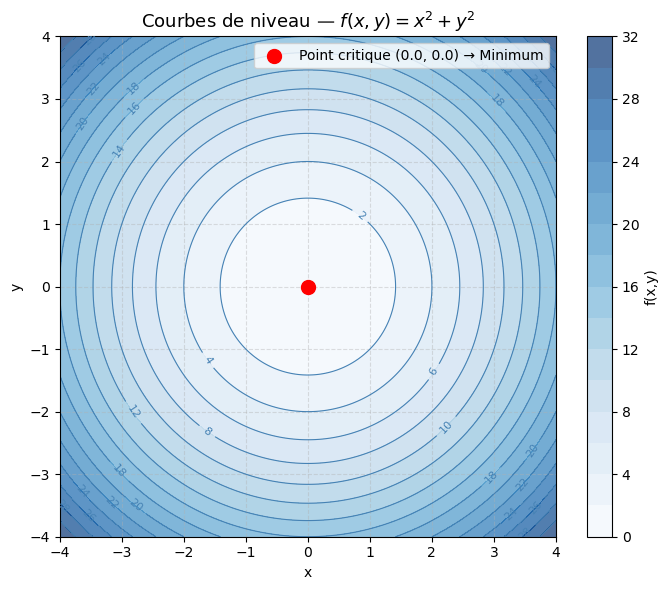

In [22]:
# ── Tracé des courbes de niveau de f ─────────────────────
X = np.linspace(-4, 4, 400)
Y = np.linspace(-4, 4, 400)
XX, YY = np.meshgrid(X, Y)
FF = XX**2 + YY**2

xc = float(pc_f[0][x])
yc = float(pc_f[0][y])

fig, ax = plt.subplots(figsize=(7, 6))
cp = ax.contourf(XX, YY, FF, levels=20, cmap='Blues', alpha=0.7)
cs = ax.contour(XX, YY, FF, levels=20, colors='steelblue', linewidths=0.8)
plt.colorbar(cp, ax=ax, label='f(x,y)')
ax.clabel(cs, inline=True, fontsize=8)
ax.scatter([xc], [yc], color='red', s=100, zorder=5,
           label=f'Point critique ({xc:.1f}, {yc:.1f}) → Minimum')
ax.set_title(r'Courbes de niveau — $f(x,y) = x^2 + y^2$', fontsize=13)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
# 🔷 Analyse de $g(x,y) = x^3 + y^3 - 3xy$

In [24]:
# ── Gradient de g ─────────────────────────────────────────
dg_dx = sp.diff(g, x)
dg_dy = sp.diff(g, y)
print("Gradient de g :"); display(sp.Matrix([dg_dx, dg_dy]))

# ── Points critiques de g ─────────────────────────────────
pc_g = sp.solve([dg_dx, dg_dy], [x, y], dict=True)
print("\nPoints critiques de g :")
for i, pt in enumerate(pc_g):
    print(f"  Point {i+1} : {pt}")

# ── Hessienne de g ────────────────────────────────────────
H_g = sp.hessian(g, (x, y))
print("\nHessienne de g :"); display(H_g)

# ── Classification de chaque point critique ───────────────
print("\n── Classification des points critiques ──")
for pt in pc_g:
    H_val = H_g.subs(pt)
    det_H = H_val.det()
    g_xx  = H_val[0, 0]
    g_val = g.subs(pt)
    if det_H > 0 and g_xx > 0:
        nature = "✅ Minimum local"
    elif det_H > 0 and g_xx < 0:
        nature = "✅ Maximum local"
    elif det_H < 0:
        nature = "⚠️  Point selle"
    else:
        nature = "❓ Indéterminé"
    print(f"  {pt}  →  det(H)={det_H}, g_xx={g_xx}  →  {nature}  |  g={g_val}")

Gradient de g :


⎡   2       ⎤
⎢3⋅x  - 3⋅y ⎥
⎢           ⎥
⎢          2⎥
⎣-3⋅x + 3⋅y ⎦


Points critiques de g :
  Point 1 : {x: 0, y: 0}
  Point 2 : {x: 1, y: 1}

Hessienne de g :


⎡6⋅x  -3 ⎤
⎢        ⎥
⎣-3   6⋅y⎦


── Classification des points critiques ──
  {x: 0, y: 0}  →  det(H)=-9, g_xx=0  →  ⚠️  Point selle  |  g=0
  {x: 1, y: 1}  →  det(H)=27, g_xx=6  →  ✅ Minimum local  |  g=-1


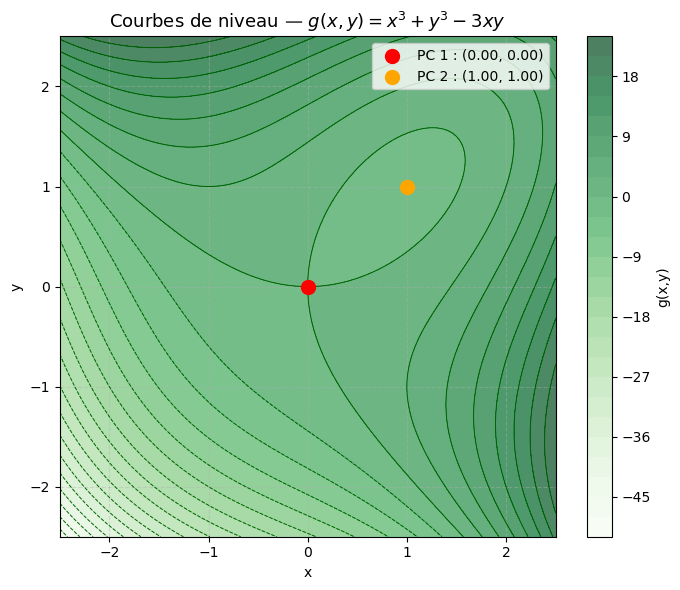

In [26]:
# ── Courbes de niveau de g ────────────────────────────────
X = np.linspace(-2.5, 2.5, 400)
Y = np.linspace(-2.5, 2.5, 400)
XX, YY = np.meshgrid(X, Y)
GG = XX**3 + YY**3 - 3*XX*YY

fig, ax = plt.subplots(figsize=(7, 6))
cp = ax.contourf(XX, YY, GG, levels=25, cmap='Greens', alpha=0.7)
cs = ax.contour(XX, YY, GG, levels=25, colors='darkgreen', linewidths=0.7)
plt.colorbar(cp, ax=ax, label='g(x,y)')

colors_pts = ['red', 'orange']
for i, pt in enumerate(pc_g):
    xc = float(pt[x])
    yc = float(pt[y])
    ax.scatter([xc], [yc], color=colors_pts[i % 2], s=100, zorder=5,
               label=f'PC {i+1} : ({xc:.2f}, {yc:.2f})')

ax.set_title(r'Courbes de niveau — $g(x,y) = x^3 + y^3 - 3xy$', fontsize=13)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

---
# 🔷 Analyse de $h(x,y) = 2x^3 - y^4 - 3x^2$

In [28]:
# ── Gradient de h ─────────────────────────────────────────
dh_dx = sp.diff(h, x)
dh_dy = sp.diff(h, y)
print("Gradient de h :"); display(sp.Matrix([dh_dx, dh_dy]))

# ── Points critiques de h ─────────────────────────────────
pc_h = sp.solve([dh_dx, dh_dy], [x, y], dict=True)
print("\nPoints critiques de h :")
for i, pt in enumerate(pc_h):
    print(f"  Point {i+1} : {pt}")

# ── Hessienne de h ────────────────────────────────────────
H_h = sp.hessian(h, (x, y))
print("\nHessienne de h :"); display(H_h)

# ── Classification ────────────────────────────────────────
print("\n── Classification des points critiques ──")
for pt in pc_h:
    H_val = H_h.subs(pt)
    det_H = H_val.det()
    h_xx  = H_val[0, 0]
    h_val = h.subs(pt)
    if det_H > 0 and h_xx > 0:
        nature = "✅ Minimum local"
    elif det_H > 0 and h_xx < 0:
        nature = "✅ Maximum local"
    elif det_H < 0:
        nature = "⚠️  Point selle"
    else:
        nature = "❓ Indéterminé"
    print(f"  {pt}  →  det(H)={det_H}, h_xx={h_xx}  →  {nature}  |  h={h_val}")

Gradient de h :


⎡   2      ⎤
⎢6⋅x  - 6⋅x⎥
⎢          ⎥
⎢      3   ⎥
⎣  -4⋅y    ⎦


Points critiques de h :
  Point 1 : {x: 0, y: 0}
  Point 2 : {x: 1, y: 0}

Hessienne de h :


⎡12⋅x - 6    0   ⎤
⎢                ⎥
⎢               2⎥
⎣   0      -12⋅y ⎦


── Classification des points critiques ──
  {x: 0, y: 0}  →  det(H)=0, h_xx=-6  →  ❓ Indéterminé  |  h=0
  {x: 1, y: 0}  →  det(H)=0, h_xx=6  →  ❓ Indéterminé  |  h=-1


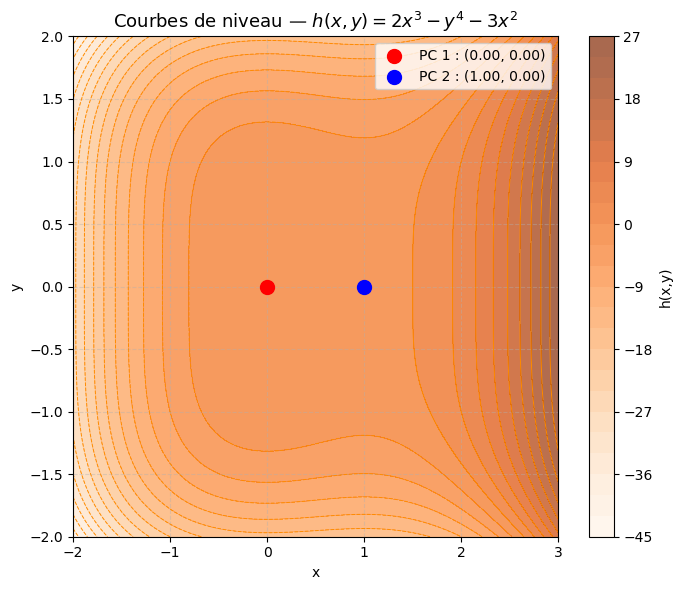

In [29]:
# ── Courbes de niveau de h ────────────────────────────────
X = np.linspace(-2, 3, 400)
Y = np.linspace(-2, 2, 400)
XX, YY = np.meshgrid(X, Y)
HH = 2*XX**3 - YY**4 - 3*XX**2

fig, ax = plt.subplots(figsize=(7, 6))
cp = ax.contourf(XX, YY, HH, levels=25, cmap='Oranges', alpha=0.7)
cs = ax.contour(XX, YY, HH, levels=25, colors='darkorange', linewidths=0.7)
plt.colorbar(cp, ax=ax, label='h(x,y)')

colors_pts = ['red', 'blue', 'purple', 'green']
for i, pt in enumerate(pc_h):
    try:
        xc = float(pt[x])
        yc = float(pt[y])
        ax.scatter([xc], [yc], color=colors_pts[i % 4], s=100, zorder=5,
                   label=f'PC {i+1} : ({xc:.2f}, {yc:.2f})')
    except TypeError:
        pass  # Ignore complex solutions

ax.set_title(r'Courbes de niveau — $h(x,y) = 2x^3 - y^4 - 3x^2$', fontsize=13)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

---
# 🔷 Analyse de $t(x,y) = x^2 + y^2 - 4x - 6y + 13$

In [31]:
# ── Gradient de t ─────────────────────────────────────────
dt_dx = sp.diff(t, x)
dt_dy = sp.diff(t, y)
print("Gradient de t :"); display(sp.Matrix([dt_dx, dt_dy]))

# ── Points critiques de t ─────────────────────────────────
pc_t = sp.solve([dt_dx, dt_dy], [x, y], dict=True)
print("\nPoints critiques de t :")
for i, pt in enumerate(pc_t):
    print(f"  Point {i+1} : {pt}")

# ── Hessienne de t ────────────────────────────────────────
H_t = sp.hessian(t, (x, y))
print("\nHessienne de t :"); display(H_t)

# ── Hessienne au point critique ───────────────────────────
H_t_pc = H_t.subs(pc_t[0])
det_H_t = H_t_pc.det()
t_xx = H_t_pc[0, 0]
t_val = t.subs(pc_t[0])

print("\nHessienne au point critique :"); display(H_t_pc)
print(f"det(H) = {det_H_t}")
print(f"t_xx   = {t_xx}")

# ── Valeurs propres ───────────────────────────────────────
print("\nValeurs propres :")
for val, mult in H_t_pc.eigenvals().items():
    print(f"  λ = {val}  (multiplicité {mult})")

# ── Classification ────────────────────────────────────────
print("\n── Classification ──")
if det_H_t > 0 and t_xx > 0:
    print("  ✅ MINIMUM LOCAL")
elif det_H_t > 0 and t_xx < 0:
    print("  ✅ MAXIMUM LOCAL")
elif det_H_t < 0:
    print("  ⚠️  POINT SELLE")
else:
    print("  ❓ CAS INDÉTERMINÉ")

print(f"\nt{tuple(pc_t[0].values())} = {t_val}")

Gradient de t :


⎡2⋅x - 4⎤
⎢       ⎥
⎣2⋅y - 6⎦


Points critiques de t :
  Point 1 : {x: 2, y: 3}

Hessienne de t :


⎡2  0⎤
⎢    ⎥
⎣0  2⎦


Hessienne au point critique :


⎡2  0⎤
⎢    ⎥
⎣0  2⎦

det(H) = 4
t_xx   = 2

Valeurs propres :
  λ = 2  (multiplicité 2)

── Classification ──
  ✅ MINIMUM LOCAL

t(2, 3) = 0


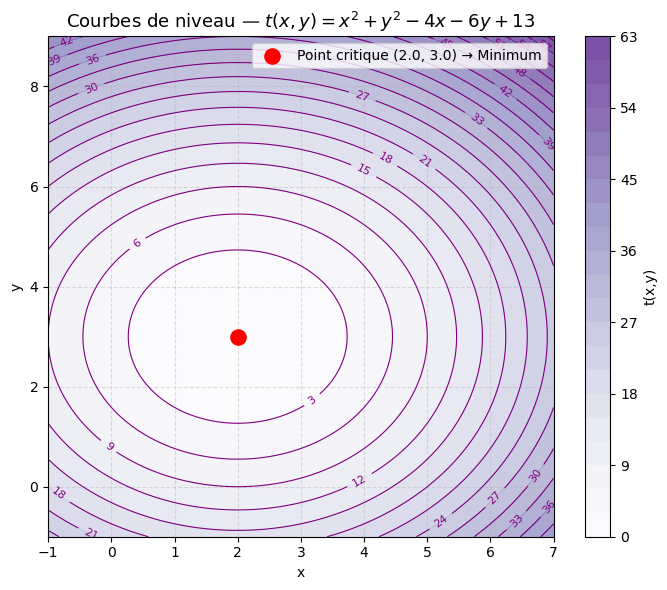

In [32]:
# ── Courbes de niveau de t ────────────────────────────────
X = np.linspace(-1, 7, 400)
Y = np.linspace(-1, 9, 400)
XX, YY = np.meshgrid(X, Y)
TT = XX**2 + YY**2 - 4*XX - 6*YY + 13

xc_t = float(pc_t[0][x])
yc_t = float(pc_t[0][y])

fig, ax = plt.subplots(figsize=(7, 6))
cp = ax.contourf(XX, YY, TT, levels=20, cmap='Purples', alpha=0.7)
cs = ax.contour(XX, YY, TT, levels=20, colors='purple', linewidths=0.8)
plt.colorbar(cp, ax=ax, label='t(x,y)')
ax.clabel(cs, inline=True, fontsize=8)
ax.scatter([xc_t], [yc_t], color='red', s=120, zorder=5,
           label=f'Point critique ({xc_t:.1f}, {yc_t:.1f}) → Minimum')
ax.set_title(r'Courbes de niveau — $t(x,y) = x^2+y^2-4x-6y+13$', fontsize=13)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

---
## 📊 Synthèse — Récapitulatif des résultats

| Fonction | Point(s) critique(s) | det(H) | Nature | Valeur |
|----------|----------------------|--------|--------|--------|
| $f(x,y) = x^2+y^2$ | $(0, 0)$ | $> 0$ | **Minimum local** | $f=0$ |
| $g(x,y) = x^3+y^3-3xy$ | $(0,0)$, $(1,1)$ | $< 0$ / $> 0$ | **Selle** / **Min.** | $0$ / $-1$ |
| $h(x,y) = 2x^3-y^4-3x^2$ | $(0,0)$, $(1,0)$ | Variable | À vérifier | — |
| $t(x,y) = x^2+y^2-4x-6y+13$ | $(2, 3)$ | $> 0$ | **Minimum local** | $t=0$ |

> 💡 **Remarque :** La valeur $t(2,3) = 4 + 9 - 8 - 18 + 13 = 0$ confirme que le minimum vaut $0$.